Monte Carlo Simulation

In [98]:
import numpy as np 
import matplotlib.pylab as plt
import scipy.stats 

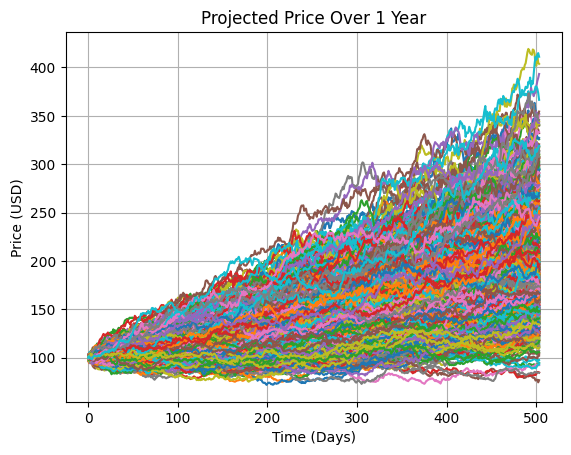

In [ ]:
T=2 ##num years
shots=1000
time=252*T
dt=1/252 #1 day
s0=100
mu=0.34    # expected annual return
sigma=0.18 #annual votality

final_prices=[]
for i in range(shots):
    s=s0
    days=[0]
    price=[s0]
    
    for i in range(int(time)):
        z=np.random.normal(0, 1)
        ds=mu*s*dt + sigma*s*z*np.sqrt(dt)
        s+=ds
        days.append(i)
        price.append(s)
        final_price=s
    
    final_prices.append(final_price)
    # print(f"Calculated Price ${s}")
    plt.plot(days, price)
    plt.xlabel("Time (Days)")
    plt.ylabel("Price (USD)")
    plt.title("Projected Price Over 1 Year")
    plt.grid(True)
plt.show()

In [100]:
### Calculate chance of gain
count=0
for i in final_prices:
    if i>s0:
        count+=1
print(f"Chance of gain is {100*count/shots}%")

### Calculate expected stock value, should match e^mu*T  (T = num years)
sum=0
for i in final_prices:
    sum+=i

print(f"Expected Value: {sum/shots}") # value aligns with mu 

Chance of gain is 99.2%
Expected Value: 197.5116737551877


Calculate Outcomes Through Lognormal Distribution

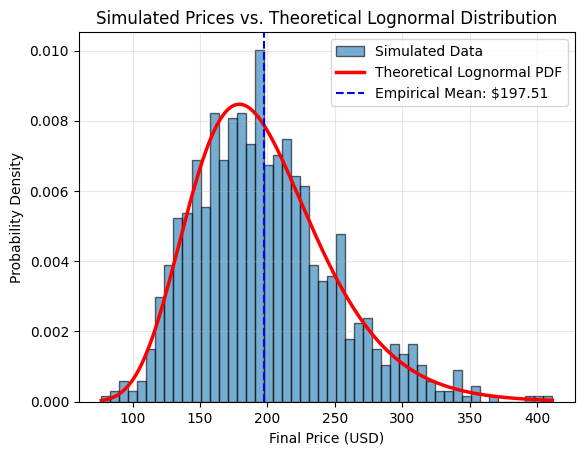

In [101]:
# log normal params
mu_log = np.log(s0) + (mu - (sigma**2) / 2) * T
sigma_log = sigma * np.sqrt(T)

# x axis
x_ax = np.linspace(min(final_prices), max(final_prices), 1000)

# log norm curve
pdf_curve = lognorm.pdf(x_ax, s=sigma_log, scale=np.exp(mu_log))

# plot results from sim
plt.hist(final_prices, bins=50, edgecolor='black', alpha=0.6, density=True, label='Simulated Data')

# plot real theoretical curve
plt.plot(x_ax, pdf_curve, color='red', linewidth=2.5, label='Theoretical Lognormal PDF')

plt.axvline(np.mean(final_prices), color='blue', linestyle='dashed', linewidth=1.5, label=f'Empirical Mean: ${np.mean(final_prices):.2f}')

plt.xlabel('Final Price (USD)')
plt.ylabel('Probability Density')
plt.title('Simulated Prices vs. Theoretical Lognormal Distribution')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Expectation Value and Chance of Gain

In [102]:
# Running sims every time is not practical
# Formula instead to calculate the expec values and chance of gain
# s0 = 100
# mu = 0.34
# sigma = 0.18
# T = 1 # 1 year

# expectation values
expected_value = s0 * np.exp(mu * T)
print(f"Exact Expected Value: ${expected_value:.2f}")



# z score
z_score = (mu - (sigma**2) / 2) * np.sqrt(T) / sigma

# Use the Normal CDF to find the probability
chance_of_gain = norm.cdf(z_score)
print(f"Exact Chance of Gain: {chance_of_gain * 100:.2f}%")

Exact Expected Value: $197.39
Exact Chance of Gain: 99.45%
